# 🍬 Candy Power Ranking — Which characteristics drive customer sentiment?

**Case study — new store-brand product decision**

The purchasing team wants to launch a **new store-brand candy** and is split between a
**cookie-based sweet** and a **gummy**. This notebook uses market data on 85 real products
to answer two questions the executive board actually cares about:

1. **Which product characteristics drive customer sentiment?**
2. **Given that, should the new product be cookie-based or a gummy — and what should it contain?**

**Data:** FiveThirtyEight _"Ultimate Halloween Candy Power Ranking"_ — 85 candies, 9 binary
attributes + sugar/price percentiles, and `winpercent` (share of ~269,000 head-to-head
matchups a candy wins). We treat `winpercent` as the **proxy for customer sentiment**: it is a
revealed-preference score, i.e. what people _chose_ when forced to pick between two candies.


## Setup


In [40]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score
from scipy import stats
sns.set_theme(style="whitegrid")

ATTR = ["chocolate","fruity","caramel","peanutyalmondy","nougat",
        "crispedricewafer","hard","bar","pluribus"]
NUM  = ["sugarpercent","pricepercent"]
TARGET = "winpercent"

df = pd.read_csv("data/candy-data.csv")
print("shape:", df.shape, "| missing:", int(df.isna().sum().sum()))
display(df.head())

shape: (85, 13) | missing: 0


,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


## 1. A glance of the data

85 candies, no missing values. The 9 attribute columns are binary ( 1 -> has the trait).
`sugarepercent` and `pricepercent` are **percentile ranks within this dataset** so they express _relateive_ sweetness/price, not grams or dollars. `winpercent` run roughly 22-84


In [41]:
df[[TARGET] + NUM].describe().round(2)

,winpercent,sugarpercent,pricepercent
count,85.00,85.00,85.00
mean,50.32,0.48,0.47
std,14.71,0.28,0.29
min,22.45,0.01,0.01
25%,39.14,0.22,0.26
50%,47.83,0.46,0.46
75%,59.86,0.73,0.65
max,84.18,0.99,0.98


## 2. What does it mean to "win" ?

Before modelling anything, look into the extremes - they tell the story on their own.


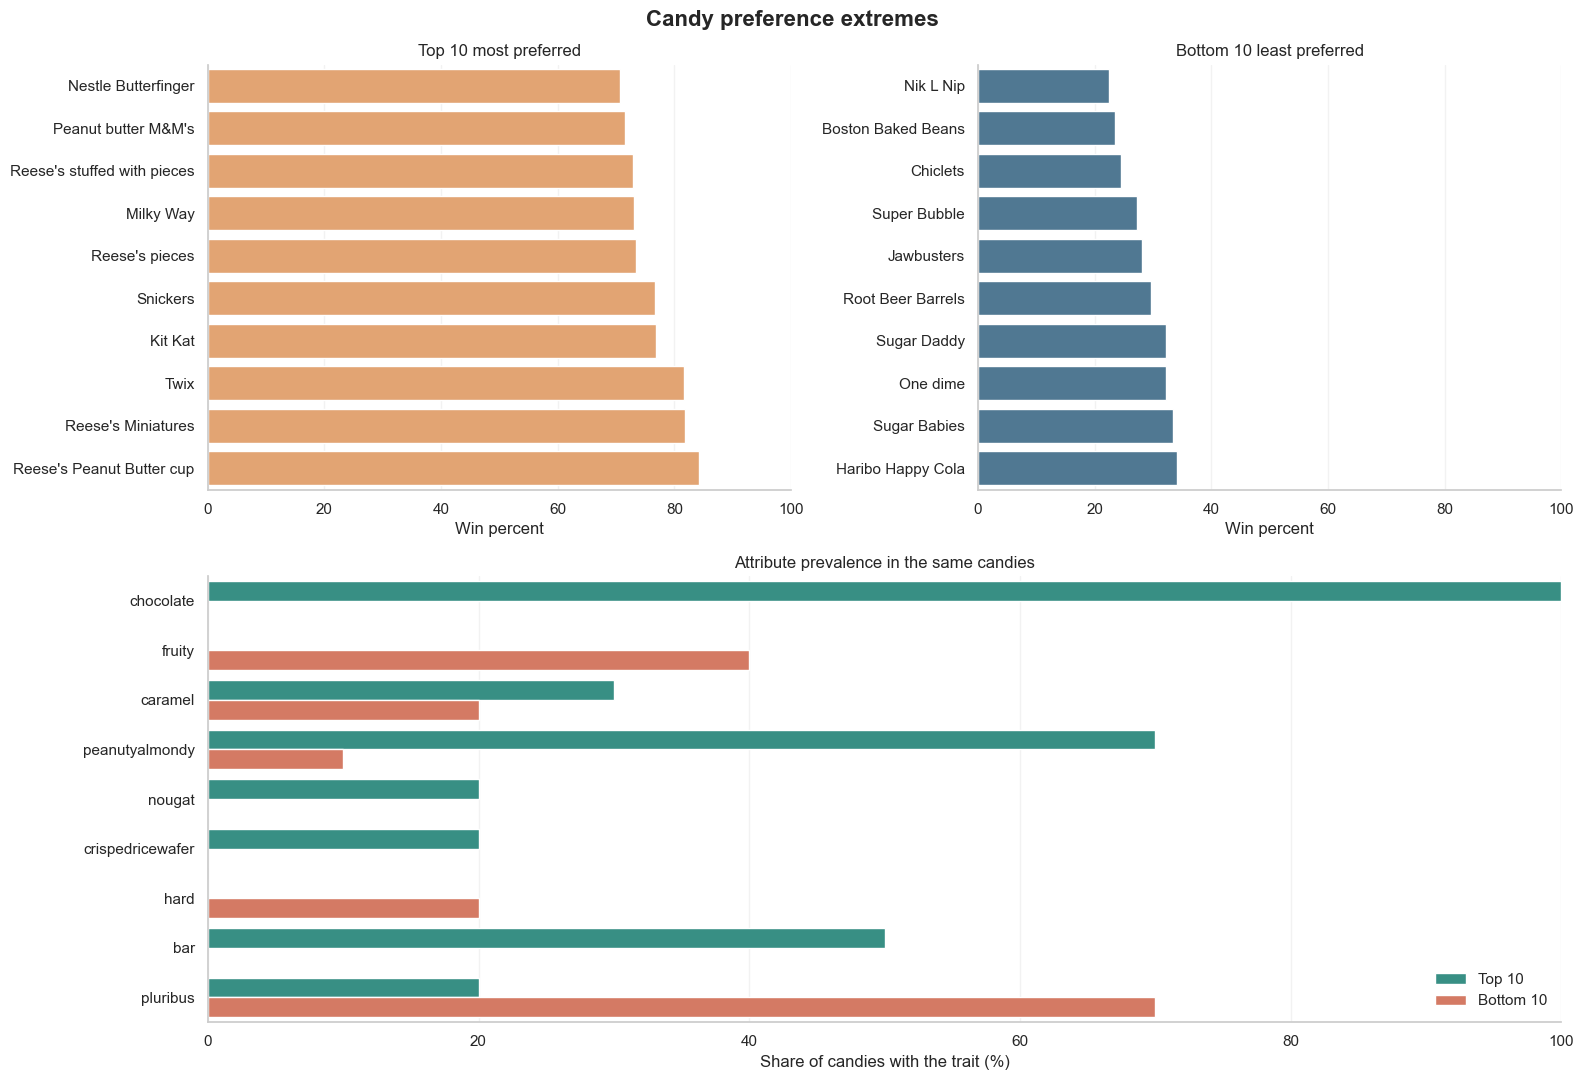

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Build a compact view of the extremes and compare their attribute profiles.
top = df.nlargest(10, TARGET)[["competitorname", TARGET] + ATTR].copy()
bottom = df.nsmallest(10, TARGET)[["competitorname", TARGET] + ATTR].copy()

attr_summary = pd.DataFrame({
    "attribute": ATTR,
    "Top 10": top[ATTR].mean().values * 100,
    "Bottom 10": bottom[ATTR].mean().values * 100,
}).melt(id_vars="attribute", var_name="group", value_name="share")

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.05])
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])]

sns.barplot(
    data=top.sort_values(TARGET, ascending=True),
    x=TARGET,
    y="competitorname",
    ax=axes[0],
    color="#f4a261",
)
axes[0].set_title("Top 10 most preferred")
axes[0].set_xlabel("Win percent")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 100)

sns.barplot(
    data=bottom.sort_values(TARGET, ascending=True),
    x=TARGET,
    y="competitorname",
    ax=axes[1],
    color="#457b9d",
)
axes[1].set_title("Bottom 10 least preferred")
axes[1].set_xlabel("Win percent")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 100)

sns.barplot(
    data=attr_summary,
    y="attribute",
    x="share",
    hue="group",
    ax=axes[2],
    palette=["#2a9d8f", "#e76f51"],
)
axes[2].set_title("Attribute prevalence in the same candies")
axes[2].set_xlabel("Share of candies with the trait (%)")
axes[2].set_ylabel("")
axes[2].set_xlim(0, 100)
axes[2].legend(title="", frameon=False, loc="lower right")

for ax in axes[:2]:
    ax.grid(axis="x", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[2].grid(axis="x", alpha=0.25)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

fig.suptitle("Candy preference extremes", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Every single one of the top 10 contains chocolate. Not one contains fruit flavoring.**

The bottom of the ranking is domindated by fruity,  hard, and bah/box ("pluribus") candies -
which is exactly the profile of a classic gummy. That pattern is the whole case study in one viz.

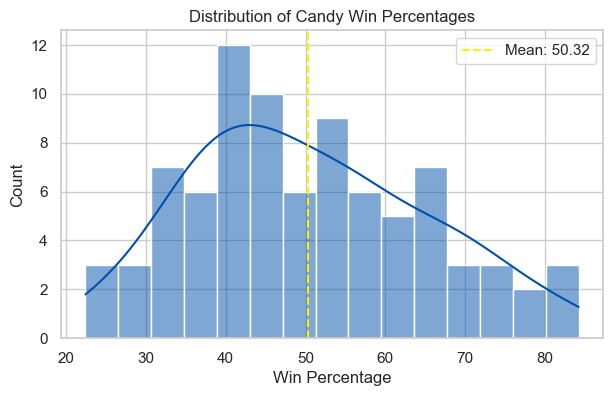

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df[TARGET], bins = 15, kde = True,ax=ax,color="#0050AA")
ax.axvline(df[TARGET].mean(), color='#FFF000', linestyle='--', label=f'Mean: {df[TARGET].mean():.2f}')
ax.set(title="Distribution of Candy Win Percentages", xlabel="Win Percentage")
ax.legend(); plt.show()

## 3. Which charecteristics drive sentiment?

Simplest view first: for each *attribute*, compare average `winpercent` **with** the 
trait vs **without** it. The gap ("lift") is how much that signle trait moves sentiment.

Lift of candy attributes on win percentage
       attribute  n_with  mean_with  mean_without  lift
       chocolate      37  60.921529     42.142257  18.8
  peanutyalmondy      14  63.697137     47.678380  16.0
crispedricewafer       8  63.648449     48.931654  14.7
             bar      21  61.295413     46.714395  14.6
          nougat       7  60.051879     49.443100  10.6
         caramel      14  57.346908     48.930538   8.4
        pluribus      44  46.822781     54.066404  -7.2
          fruity      38  44.119741     55.327122 -11.2
            hard      14  40.117064     52.327972 -12.2


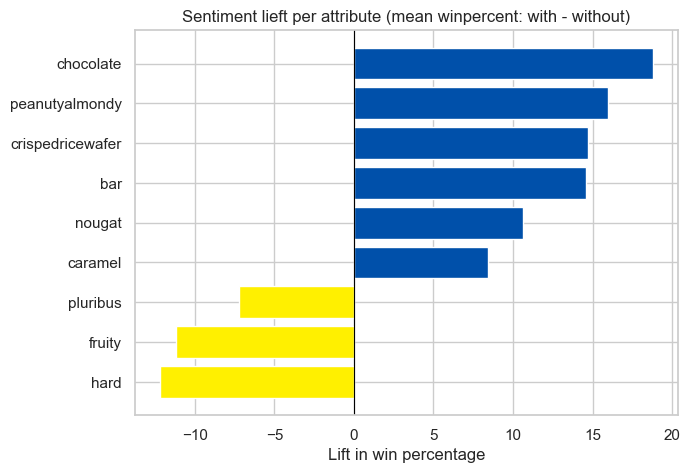

In [44]:
rows = []

for a in ATTR:
    yes = df.loc[df[a] == 1, TARGET].mean()
    no = df.loc[df[a] == 0, TARGET].mean()
    rows.append({"attribute": a, "n_with":int((df[a] == 1).sum()),
                 "mean_with": yes, "mean_without": no,"lift":round(yes-no,1 )})

lift = pd.DataFrame(rows).sort_values("lift", ascending=False).reset_index(drop=True)
print("Lift of candy attributes on win percentage")
print(lift.to_string(index=False))

fix, ax = plt.subplots(figsize=(7, 5))
colors = ["#0050AA" if v>0 else "#FFF000" for v in lift["lift"]]
ax.barh(lift["attribute"], lift["lift"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Sentiment lieft per attribute (mean winpercent: with - without)", xlabel="Lift in win percentage")
ax.invert_yaxis(); plt.show()

**Positive drivers:**
1. chocolate(+18.8)
2. peanut/almond (+16.0)
3. crisped-rice/wafer i.e. the **cookie component** (*14.7)
4. bar format (+14.6)
5. caramel
6. nougat
---
**Negative drivers:**
1. hard(-12.2)
2. fruity (-11.2)
3. bag/box/pluribus (-7.2)
---
Note : The negative traits (fruity, hard, pluribus) are precisely the defining features of a **gummy**. The positive traits describe a **chocolate cookie bar**

## 4. Regression + a non-linear cross-check

The signle-trait view ignoers that traits travel together(most bars are also chocolate).
So fit two models on all attributes at once:

- **Linear regression** - interpretable coefficients (predictors are 0-1 / percentile-scaled,
so magnitues are broadly comparable).
- **Random forst + permutation importance** - captures interactions and non-linearity, and acts as an independent sanity check on a small sample.

Linear Regression R² (in-sample): 0.54 | R² (5-fold cross-validated): 0.18
Linear Regression Coefficients:
chocolate           19.75
peanutyalmondy       9.74
sugarpercent         9.60
fruity               9.12
crispedricewafer     7.48
caramel              2.21
bar                  0.39
nougat               0.30
pluribus            -1.35
pricepercent        -5.25
hard                -6.67


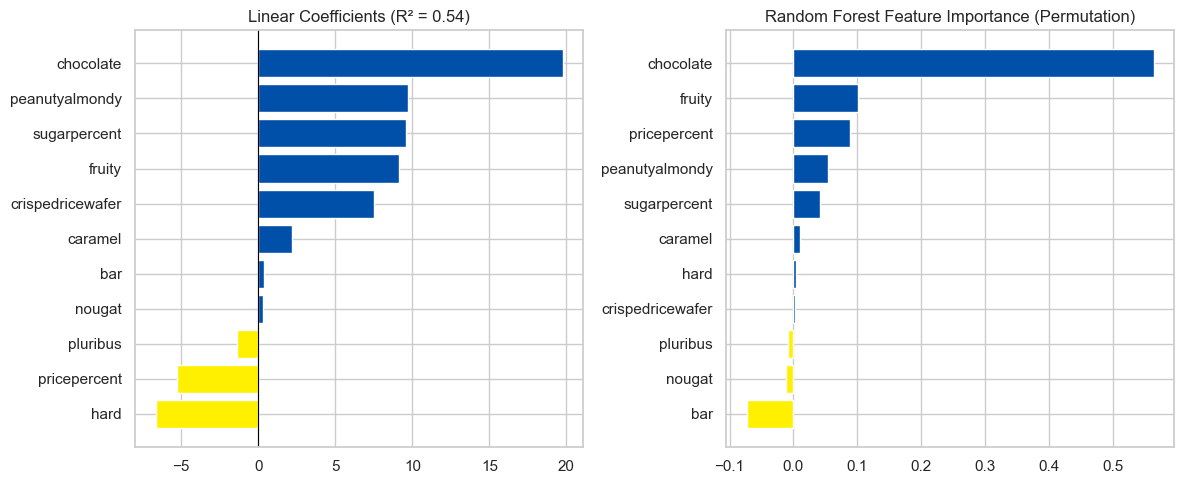

In [45]:
X ,y = df[ATTR+NUM], df[TARGET]

lin = LinearRegression().fit(X, y)
coef = pd.Series(lin.coef_, index=X.columns).sort_values(ascending=False)
r2_in = lin.score(X, y)
r2_cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2').mean()
print(f"Linear Regression R² (in-sample): {r2_in:.2f} | R² (5-fold cross-validated): {r2_cv:.2f}")
print("Linear Regression Coefficients:")
print(coef.round(2).to_string())

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=500, random_state=42).fit(Xtr, ytr)
perm = permutation_importance(rf, Xte, yte, n_repeats=50, random_state=42)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1,2,figsize=(12, 5))
c = coef.sort_values()
axes[0].barh(c.index, c.values, color=["#0050AA" if v>0 else "#FFF000" for v in c])
axes[0].axvline(0, color="black", linewidth=0.8); axes[0].set_title(f"Linear Coefficients (R² = {r2_in:.2f})")
i = imp.sort_values()
axes[1].barh(i.index, i.values, color=["#0050AA" if v>0 else "#FFF000" for v in i]); axes[1].set_title("Random Forest Feature Importance (Permutation)")
plt.tight_layout(); plt.show()

Both models agree on **chocolate being the dominant driver by a wide margin**, followed by the peanut/almond, the druity penalty, and the cookie (crisped-rice/wafer) component

**Note** :  in-sample R² = 0.54 but 5-fold cross-validated R² is much lower(~0.18).
With only 85 rows and 11 predictors the model is good at telling us the **direction and randking of drivers**, but should **not** be trusted for precise point predictions.
We use it as a compass, not a GPS.

## 5. Cookie vs Gummy

The datset has no "cookie" or "gummy" label, so we buld transparent "proxies".

- **Cookie/wafer proxy** = `crispedricewafer == 1` ( the only baked/cookie-component field).
- **Gummy proxy** = `fruity & not hard & pluribus & not chocolate` (soft , fruit flavored, sold many-to-a-pack, no chokolate/cookie) 

In [46]:
df["seg_cookie"] = df["crispedricewafer"] == 1
df["seg_gummy"] = (df["fruity"] == 1)&(df["hard"]==0)&(df["pluribus"]==1)&(df["chocolate"]==0)

ck = df.loc[df["seg_cookie"], TARGET]
gm = df.loc[df["seg_gummy"], TARGET]
rest = df.loc[~(df["seg_cookie"]|df["seg_gummy"]), TARGET]
print(f"Cookie/wafe proxy : n={len(ck)}   mean_win={ck.mean():.2f} std={ck.std():.2f}")
print(f"Gummy proxy       : n={len(gm)}  mean_win={gm.mean():.2f} std={gm.std():.2f}")
print(f"All other candies : n={len(rest)}  mean_win={rest.mean():.2f} std={rest.std():.2f}")

t, p = stats.ttest_ind(ck , gm , equal_var=False)

print(f"\nCookie vs Gummy: +{ck.mean()-gm.mean():.1f} pts | Welch  t={t:.2f} p={p:.4f}")

Cookie/wafe proxy : n=8   mean_win=63.65 std=12.22
Gummy proxy       : n=20  mean_win=46.63 std=11.59
All other candies : n=58  mean_win=49.67 std=15.04

Cookie vs Gummy: +17.0 pts | Welch  t=3.38 p=0.0053


**Cookie-based candies beat gummies by ~17 winpercent point, and the differnce is statistically significant (p ≈ 0.005) despite the small sample.** Gummies sti *below* the overall average; cookie/wafer products sit well above it.

## 6. Does a premium price position pay off?

Useful for pricing the store brand: is there room to position above the cheapest tier?

corr(price, win = 0.35
corr(sugar, win = 0.23
cheaper half mean_win = 45.1) | premium half mean_win = 55.7


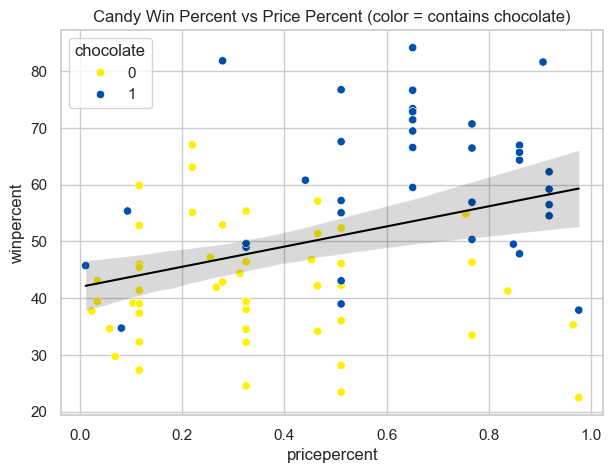

In [59]:
print(f"corr(price, win = {df['pricepercent'].corr(df[TARGET]):.2f}")
print(f"corr(sugar, win = {df['sugarpercent'].corr(df[TARGET]):.2f}")   
lo = df[df.pricepercent <= df.pricepercent.median()][TARGET].mean()
hi = df[df.pricepercent > df.pricepercent.median()][TARGET].mean()
print(f"cheaper half mean_win = {lo:.1f}) | premium half mean_win = {hi:.1f}")

fig, ax  = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="pricepercent", y=TARGET, hue="chocolate", palette={0: "#FFF000" ,1: '#0050AA'}, ax=ax)
sns.regplot(data=df, x="pricepercent", y=TARGET, scatter=False, ax=ax, color="black", line_kws={"linewidth":1.5})
ax.set_title("Candy Win Percent vs Price Percent (color = contains chocolate)")
plt.show()

Price has a **mild positive** relationship with sentiment(r ≈ 0.35), but the chart shows this is largery beacuse **premium candies tend to be the chocolate ones.**

The lever is the `chocolate`, not the price tag. Implication: a quality chocolate cookie productcan justify a mid/premium store-brand price, sentiment won't punish it.

## 7. Scoring candidate product concepts

Using the linear model as a directional score, we predict dentiment for concrete product concepts (sugar & price held at dataset median). 
Note: Ranking provision, not precise values

(dataset mean winpercent = 50.3)
Predicted win percentages by concept:
Chocolate + Peanut bar                  66.4
Chocolate + Caramel + wafer bar         66.4
Chocolate wafer bar (classic cookie)    64.2
Chocolate-coated bites (gummy hedge)    54.9
Plain fruity gummy                      44.3


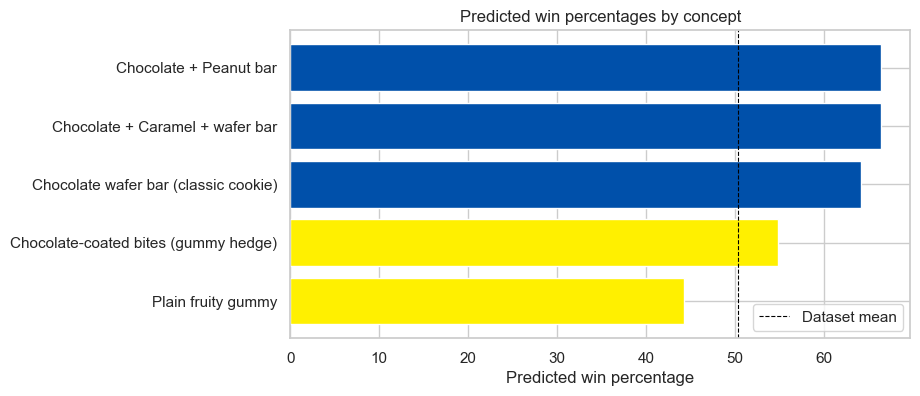

In [71]:
med_s , med_p = df.sugarpercent.median(), df.pricepercent.median()

def concept(**kw):
    row = {a:0 for a in ATTR}
    row.update(kw)
    row["sugarpercent"], row["pricepercent"] = med_s, med_p
    return pd.DataFrame([row])[ATTR+NUM]

concepts = {
    "Chocolate + Peanut bar" : dict(chocolate=1, peanutyalmondy=1, bar=1),
    "Chocolate + Caramel + wafer bar": dict(chocolate=1, caramel=1, crispedricewafer=1, bar=1),
    "Chocolate wafer bar (classic cookie)" : dict(chocolate=1, crispedricewafer=1, bar=1),
    "Chocolate-coated bites (gummy hedge)" : dict(chocolate=1,pluribus=1),
    "Plain fruity gummy": dict(fruity=1,pluribus=1),
}

scores = {name: round(float(lin.predict(concept(**kw))[0]), 1) for name, kw in concepts.items()}
res = pd.Series(scores).sort_values(ascending=False)

print(f"(dataset mean winpercent = {df[TARGET].mean():.1f})")
print("Predicted win percentages by concept:")
print(res.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(res.index, res.values, color=["#FFF000" if "gummy" in n.lower() or "fruity" in n.lower() else "#0050AA" for n in res.index])
ax.axvline(df[TARGET].mean(), color="black", ls="--", linewidth=0.8, label="Dataset mean")
ax.set(title="Predicted win percentages by concept", xlabel="Predicted win percentage")
ax.invert_yaxis()
ax.legend(); plt.show()

**Chocolat cookie/bar concepts land ~ 65; a plain fruity gummy lands ~ 44.**
Adding a chocolate coating to a bite-sized ("gummy-format") product recoves ~10 points, a useful hedge if the team is set on a bit format.

## 8. Recommendation & assumptions

### Recommendation
** Launch a chocolate-based cookie/wafer bar**, ideally combined with **peanut/almond or
caramel**. This aligns with the signle strongest sentiment driver (Chocolate) and the
cookie component, and avoids the two biggest sentiment penalties (fruity, hard). A gummy
starts ~17 points lower on sentiment . If a bit format is strategically required, a
**chocolate-coated bite** is the sentiment-optimal compromise.

### Key assumptions
1. `winpercent` = customer sentiment (revealed head-to-head preference, not a survey)
2. "Cookie" and "gummy" are proxues built from available fields (no texture label exists)
3. Store-brand preference behaves like the national brands in the data (no store-brand flag to verify)
4. `sugar`/`price` are **relative percentiles**, not absolute values

### Limitations
- Small sample (n=85); cross validated R² is modest -> results are **directional**, not precise
- Attributes are correlated (most bars are chocolate) - coefficients share credit.